# Numerical Methods in Physics
## Lecture 3: Numerical Differentiation

**Focus:**
1. [Finite Difference Fundamentals & Error Dynamics](#session-1)
2. [High-Order Stencils & Richardson Extrapolation](#session-2)
3. [Complex-Step & Spectral Differentiation](#session-3)

---


## 1. Introduction

In numerical analysis, we often encounter functions defined only by discrete data points or differential equations that cannot be solved analytically. **Finite Difference (FD)** methods allow us to approximate derivatives using algebraic combinations of function values at discrete points.

This session builds the mathematical foundation for FD methods. We will:

- Derive approximation stencils using **Taylor Series**.
- Analyze the two competing sources of error: **Truncation (Math)** and **Round-off (Machine)**.
- Identify the "Step Size Dilemma" and the optimal $h$.


## 2. Taylor Series

The basis for all finite difference approximations is the Taylor Series expansion. Keep in mind then that this means all the discussion that comes next is only valid for analytic functions. For a sufficiently smooth function $f(x)$ centered at $x$, the value at a neighboring point $x+h$ is:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2!}f''(x) + \frac{h^3}{3!}f'''(x) + \frac{h^4}{4!}f^{(4)}(x) + \dots$$

Similarly, for a backward step $x-h$:

$$f(x-h) = f(x) - hf'(x) + \frac{h^2}{2!}f''(x) - \frac{h^3}{3!}f'''(x) + \frac{h^4}{4!}f^{(4)}(x) - \dots$$

We will refer to these expansions continuously to derive our "stencils."


## 3. Deriving First Derivative Stencils


### 3.1 Forward Difference (First Order)

We want to solve for $f'(x)$. We take the expansion for $f(x+h)$:

$$f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(\xi)$$

where $\xi \in [x, x+h]$ represents the remainder term. Rearranging to isolate $f'(x)$:

$$hf'(x) = f(x+h) - f(x) - \frac{h^2}{2}f''(\xi)$$

Divide by $h$:

$$f'(x) = \underbrace{\frac{f(x+h) - f(x)}{h}}_{\text{Forward Difference}} - \underbrace{\frac{h}{2}f''(\xi)}_{\text{Truncation Error}}$$

**Result**:
The Forward Difference approximation is First-Order Accurate, denoted as $O(h)$.



### 3.2 Backward Difference (First Order)

Using the expansion for $f(x-h)$:

$$f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(\xi)$$

Rearranging for $f'(x)$:

$$hf'(x) = f(x) - f(x-h) + \frac{h^2}{2}f''(\xi)$$

$$f'(x) = \underbrace{\frac{f(x) - f(x-h)}{h}}_{\text{Backward Difference}} + O(h)$$

**Result**:
The Forward Difference approximation is First-Order Accurate, denoted as $O(h)$.


### 3.3 Central Difference (Second Order)

To get higher accuracy, we can eliminate the $O(h)$ error term. Let's subtract the backward expansion from the forward expansion.

$$\begin{aligned}
f(x+h) &= f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \dots \\
f(x-h) &= f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \dots
\end{aligned}$$

Subtracting the second line from the first:

$$f(x+h) - f(x-h) = (f(x)-f(x)) + (h - (-h))f'(x) + \left(\frac{h^2}{2} - \frac{h^2}{2}\right)f''(x) + \left(\frac{h^3}{6} - \left(-\frac{h^3}{6}\right)\right)f'''(x) + \dots$$

$$f(x+h) - f(x-h) = 2hf'(x) + 0 + \frac{2h^3}{6}f'''(\xi)$$

Isolate $f'(x)$:

$$2hf'(x) = f(x+h) - f(x-h) - \frac{h^3}{3}f'''(\xi)$$

$$f'(x) = \underbrace{\frac{f(x+h) - f(x-h)}{2h}}_{\text{Central Difference}} - \underbrace{\frac{h^2}{6}f'''(\xi)}_{\text{Truncation Error}}$$

**Result**:
The Central Difference is **Second-Order Accurate**, denoted as $O(h^2)$. This is generally preferred over one-sided differences because the error decays much faster as $h \to 0$.


### 3.4 Five-Point Stencil (Fourth Order)

To achieve even higher accuracy ($O(h^4)$), we need to eliminate error terms up to $h^3$. This requires more information (more grid points). We utilize points at $x \pm h$ and $x \pm 2h$.

First, write the Taylor expansions up to the fifth order terms:

$$\begin{aligned} f(x \pm h) &= f(x) \pm hf' + \frac{h^2}{2}f'' \pm \frac{h^3}{6}f''' + \frac{h^4}{24}f^{(4)} \pm \frac{h^5}{120}f^{(5)} \\ f(x \pm 2h) &= f(x) \pm 2hf' + \frac{4h^2}{2}f'' \pm \frac{8h^3}{6}f''' + \frac{16h^4}{24}f^{(4)} \pm \frac{32h^5}{120}f^{(5)} \end{aligned}$$

Subtract the negative steps from the positive steps to eliminate even derivatives ($f'', f^{(4)}$):

$$f(x+h) - f(x-h) = 2hf' + \frac{h^3}{3}f''' + \frac{h^5}{60}f^{(5)} \quad \dots(1)$$

$$f(x+2h) - f(x-2h) = 4hf' + \frac{8h^3}{3}f''' + \frac{32h^5}{60}f^{(5)} \quad \dots(2)$$

We now have a system with two unknowns of interest ($f'$ and $f'''$). To solve for $f'$ with fourth-order accuracy, we must eliminate the leading error term $f'''$ (associated with $h^3$). Note that the coefficient of $f'''$ in (2) is 8 times that in (1).

Multiply equation (1) by 8:

$$8[f(x+h) - f(x-h)] = 16hf' + \frac{8h^3}{3}f''' + \frac{8h^5}{60}f^{(5)}$$

Subtract equation (2) from this result:

$$8[f(x+h) - f(x-h)] - [f(x+2h) - f(x-2h)] = (16h - 4h)f' + \left(\frac{8h^3}{3} - \frac{8h^3}{3}\right)f''' + O(h^5)$$

Simplifying the LHS and RHS:

$$-f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h) = 12hf' + O(h^5)$$

Solving for $f'(x)$:

$$f'(x) = \underbrace{\frac{-f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h)}{12h}}_{\text{Five-Point Central Difference}} + O(h^4)$$

**Result**:
This stencil is **Fourth-Order Accurate**. It requires two neighbors on each side but yields significantly higher precision for the same step size $h$ compared to the standard central difference.

## 4. The Second Derivative Stencil

We want an approximation for $f''(x)$. Instead of subtracting the Taylor expansions, let's add them.

$$\begin{aligned}
f(x+h) &= f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f^{(4)}(\xi_1) \\
f(x-h) &= f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + \frac{h^4}{24}f^{(4)}(\xi_2)
\end{aligned}$$

Adding these equations:

$$f(x+h) + f(x-h) = 2f(x) + 0 + \frac{2h^2}{2}f''(x) + 0 + \frac{2h^4}{24}f^{(4)}(\xi)$$

Simplify:

$$f(x+h) + f(x-h) = 2f(x) + h^2 f''(x) + \frac{h^4}{12}f^{(4)}(\xi)$$

Rearrange to isolate $f''(x)$:

$$h^2 f''(x) = f(x+h) - 2f(x) + f(x-h) - \frac{h^4}{12}f^{(4)}(\xi)$$

Divide by $h^2$:

$$f''(x) = \underbrace{\frac{f(x+h) - 2f(x) + f(x-h)}{h^2}}_{\text{Central Difference for } f''} - \underbrace{\frac{h^2}{12}f^{(4)}(\xi)}_{\text{Truncation Error}}$$

**Result**:
This standard stencil for the second derivative is **Second-Order Accurate** ($O(h^2)$).


## 5. Analytic Convergence

Before addressing computational limitations, it is useful to define **convergence** in the analytic sense (assuming perfect arithmetic).

A finite difference method is said to be **convergent** if the truncation error approaches zero as the step size $h$ approaches zero:

$$\lim_{h \to 0} | f'_{\text{approx}}(h) - f'_{\text{exact}} | = 0$$

The **rate of convergence** is determined by the order $p$ in the truncation error term $O(h^p)$. This integer $p$ tells us how quickly the error vanishes.

1. **Linear Convergence** ($p=1$): Methods like Forward and Backward Difference are $O(h)$.
    * Behavior: Halving the step size ($h \to h/2$) cuts the error roughly in half.
    * Cost: To gain one digit of accuracy (reduce error by factor of 10), we must reduce $h$ by a factor of 10.
2. **Quadratic Convergence** ($p=2$): The Central Difference method is $O(h^2)$.
    * Behavior: Halving the step size ($h \to h/2$) reduces the error by a factor of 4 ($2^2$).
    * Cost: To gain one digit of accuracy, we only need to reduce $h$ by a factor of $\sqrt{10} \approx 3.16$. This is much more efficient.
3. **Quartic Convergence** ($p=4$): The Five-Point Stencil is $O(h^4)$.
    * Behavior: Halving the step size ($h \to h/2$) reduces the error by a factor of 16 ($2^4$).
    * Cost: To gain one digit of accuracy, we only need to reduce $h$ by a factor of $\sqrt[4]{10} \approx 1.78$.

**Conclusion**: In an analytic framework, we would always choose $h$ to be as small as possible, and higher-order methods would always be superior because they converge to the true value significantly faster.



## 6. Connection to Interpolation

It is insightful to understand that finite difference stencils are not arbitrary algebraic tricks; they are fundamentally connected to **polynomial interpolation**.

### 6.1 Local Polynomial Interpolation

A finite difference approximation for $f'(x)$ using $N$ points is equivalent to:

1. Constructing the unique polynomial $P_{N-1}(x)$ of degree $N-1$ that passes through those $N$ points.

2. Analytically differentiating that polynomial.

3. Evaluating $P'_{N-1}(x)$ at the desired point.

**Example: The Central Difference**
Consider the points $x-h, x, x+h$ with values $f_{i-1}, f_i, f_{i+1}$. There is a unique quadratic polynomial (parabola) passing through these three points.
Let $P_2(t)$ be the polynomial where $t$ is the local coordinate relative to $x$.


$$P_2(t) = A t^2 + B t + C$$


At $t=0$ (point $x$), $P_2(0) = f_i \implies C = f_i$.
At $t=h$, $P_2(h) = f_{i+1}$.
At $t=-h$, $P_2(-h) = f_{i-1}$.

Solving for $B$ (the linear coefficient, which corresponds to the first derivative at $t=0$):


$$P_2(h) - P_2(-h) = (Ah^2 + Bh + C) - (Ah^2 - Bh + C) = 2Bh$$

$$f_{i+1} - f_{i-1} = 2Bh \implies B = \frac{f_{i+1} - f_{i-1}}{2h}$$


Since $P'_2(t) = 2At + B$, at $t=0$, $P'_2(0) = B$. Thus, the derivative of the interpolating parabola is exactly the central difference stencil.

**Implication:**
Finite difference methods essentially approximate the function locally by a polynomial of degree equal to the order of the stencil minus one (roughly). Higher-order FD methods correspond to fitting higher-degree polynomials to wider stencils.

### 6.2 Spline Interpolation (Global)

While Finite Differences typically imply local polynomials (a different polynomial is defined for every grid point $i$ using only its immediate neighbors), **Spline Interpolation** constructs a **global** piecewise polynomial.

- **Cubic Splines**: A cubic spline is a set of cubic polynomials (one per interval) connected such that the function values, first derivatives ($f'$), and second derivatives ($f''$) are continuous across all knots.

- **The Difference**: To compute the derivative at node $i$ using a cubic spline, you must solve a global tridiagonal system that couples all points in the domain together.

- **Implicit vs. Explicit**:
    - **Explicit FD**: $f'_i$ depends only on neighbors (e.g., $f_{i-1}, f_{i+1}$). This is local.
    - **Spline/Compact FD**: $f'_i$ depends on neighbors AND the derivatives at neighbors ($f'_{i-1}, f'_{i+1}$). This requires solving a matrix equation.

Spline-derived derivatives (often called **Compact Finite Differences** or **Padé schemes**) generally offer **spectral-like resolution** (higher accuracy for a given number of points) compared to standard explicit FD, but they come at the computational cost of solving a linear system rather than just performing a weighted sum.

## 7. Error Dynamics: The "V-Curve"

In a perfect mathematical world, taking $h \to 0$ would give us the exact derivative. In the computational world, we are limited by floating-point representation. The Total Error is the sum of two competing forces:

$$E_{\text{total}}(h) = |E_{\text{truncation}}| + |E_{\text{round-off}}|$$


### 7.1 Truncation Error ($E_t$)

This is the mathematical error derived in previous sections. It depends on the higher-order derivatives of the function we are approximating.

- **Forward Difference**: $E_t \approx \frac{h}{2} |f''(\xi)|$

- **Backward Difference**: $E_t \approx \frac{h}{2} |f''(\xi)|$

- **Central Difference (3-pt)**: $E_t \approx \frac{h^2}{6} |f'''(\xi)|$

- **Central Difference (5-pt)**: $E_t \approx \frac{h^4}{30} |f^{(5)}(\xi)|$

Note that for all these methods, **$E_t$ decreases as $h$ decreases**.


### 7.2 Round-off Error ($E_r$)

Computer arithmetic has limited precision (Machine Epsilon, $\epsilon \approx 10^{-16}$ for double precision).
Let $\tilde{f}(x)$ be the computed value of $f(x)$. The error in a single evaluation is roughly $\epsilon |f(x)|$.

For the Forward Difference $\frac{f(x+h) - f(x)}{h}$, the worst-case round-off error occurs when errors add up:

$$E_r \approx \left| \frac{(f(x+h) + \epsilon) - (f(x) - \epsilon)}{h} - \frac{f(x+h)-f(x)}{h} \right| = \frac{2\epsilon}{h}$$

(Assuming $|f(x)| \approx 1$ for simplicity).
Note that $E_r$ increases as $h$ decreases (dividing by a tiny number explodes the noise).


### 7.3 The Step Size Dilemma (Optimization)

The total error bound is:

$$E(h) \approx \frac{M h}{2} + \frac{2\epsilon}{h}$$

To find the optimal step size $h^*$, we minimize $E(h)$ by setting $\frac{dE}{dh} = 0$:

$$\frac{dE}{dh} = \frac{M}{2} - \frac{2\epsilon}{h^2} = 0$$

Solving for $h$:

$$\frac{M}{2} = \frac{2\epsilon}{h^2} \implies h^2 = \frac{4\epsilon}{M} \implies h = 2\sqrt{\frac{\epsilon}{M}}$$

Assuming $M \approx 1$:

$$h^* \approx \sqrt{\epsilon_{\text{mach}}}$$

### 7.4 General Derivation for Order $p$

We can generalize this for any finite difference method of order $p$.

- Truncation error scales as **$O(h^p)$**, so **$E_t \approx C_1 h^p$**.

- Round-off error always scales inversely with $h$, so $E_r \approx \frac{C_2 \epsilon}{h}$.
    - **Why $h^{-1}$?** Regardless of the method's order (2-point, 5-point, etc.), a first derivative approximation fundamentally involves dividing differences in $f(x)$ by $h$. The noise in the numerator (sums of $\epsilon$) is roughly constant times $\epsilon$, so dividing by $h$ amplifies this noise linearly as $h \to 0$.

The total error is:

$$E(h) \approx C_1 h^p + \frac{C_2 \epsilon}{h}$$

Differentiating with respect to $h$ to find the minimum:

$$\frac{dE}{dh} = p C_1 h^{p-1} - \frac{C_2 \epsilon}{h^2} = 0$$

Rearranging to solve for $h$:

$$p C_1 h^{p-1} = \frac{C_2 \epsilon}{h^2}$$

$$h^{p-1} \cdot h^2 = \frac{C_2 \epsilon}{p C_1}$$

$$h^{p+1} = \frac{C_2}{p C_1} \epsilon$$

Taking the $(p+1)$-th root:

$$h^* \approx \left( \frac{C_2}{p C_1} \right)^{\frac{1}{p+1}} \epsilon^{\frac{1}{p+1}}$$

Ignoring constants, we get the fundamental scaling law:

$$h^* \sim \epsilon^{\frac{1}{p+1}}$$

And so the minimum possible total error scales with the order of differentiation formula $p$ as:

**$$E(h) \approx C_1 \left( \frac{C_2}{p C_1} \right)^{\frac{p}{p+1}} \epsilon^\frac{p}{p+1} + C_2 \left( \frac{p C_1}{C_2} \right)^{\frac{1}{p+1}} \epsilon^\frac{p}{p+1} \approx C_* \epsilon^\frac{p}{p+1}$$**



**Key Takeaways:**

1. **Regime 1 (Large $h$)**: Truncation error dominates. The slope on a log-log plot is positive (1 for forward diff, 2 for central).

2. **Regime 2 (Tiny $h$)**: Round-off error dominates (catastrophic cancellation). The slope is negative (-1).

3. **The Sweet Spot ($h^*$)**: The optimal step size scales as $h^* \sim \epsilon^{1/(p+1)}$, where $p$ is the order of accuracy.
    - **Forward/Backward** ($p=1$): $h^* \approx \epsilon^{1/2} \approx 10^{-8}$.
    - **Central Difference** ($p=2$): $h^* \approx \epsilon^{1/3} \approx 10^{-5}$.
    - **Five-Point Stencil** ($p=4$): $h^* \approx \epsilon^{1/5} \approx 10^{-3.2} \approx 10^{-3}$.

**Insight**: As the order of the method increases, the optimal step size **$h^*$ increases** (we hit the noise floor earlier), but the minimum achievable **total error decreases** ($\sim \epsilon^{p/(p+1)}$). This places a fundamental limit on precision: we cannot simply decrease $h$ forever; higher-order methods are required to extract more precision from double-point arithmetic.

## 8. Examples

We will compute the derivative of $f(x) = e^x$ at $x=0$.

- **Exact**: $f'(0) = 1$.

- **Method**: Forward Difference vs. Central Difference.

- **Plot**: Log-Log plot of Error vs. $h$.

We expect to see a "V-Curve" where the error decreases, hits a minimum, and then shoots back up due to machine precision noise.

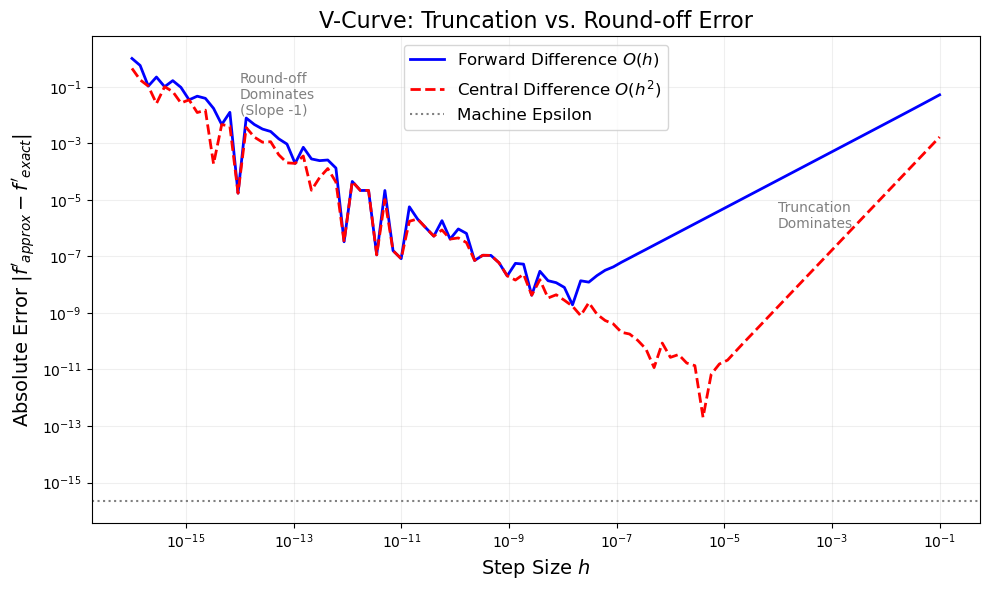

Optimal h for Forward Difference observed approx: 1.519911082952933e-08
Optimal h for Central Difference observed approx: 4.037017258596549e-06


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return np.exp(x)


def df_exact(x):
    return np.exp(x)


def forward_diff(f, x, h):
    return (f(x + h) - f(x)) / h


def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)


# Setup
x0 = 0
true_val = df_exact(x0)

# Generate a range of h values from 10^-16 to 10^-1
# We use geomspace to get evenly spaced points on a log scale
h_values = np.geomspace(1e-16, 1e-1, num=100)

# Calculate errors
error_forward = []
error_central = []

for h in h_values:
    # Forward Difference
    deriv_fwd = forward_diff(f, x0, h)
    err_fwd = abs(deriv_fwd - true_val)
    error_forward.append(err_fwd)

    # Central Difference
    deriv_cent = central_diff(f, x0, h)
    err_cent = abs(deriv_cent - true_val)
    error_central.append(err_cent)

# Plotting
plt.figure(figsize=(10, 6))

# Plot Forward Difference Error
plt.loglog(
    h_values,
    error_forward,
    label="Forward Difference $O(h)$",
    linewidth=2,
    color="blue",
)

# Plot Central Difference Error
plt.loglog(
    h_values,
    error_central,
    label="Central Difference $O(h^2)$",
    linewidth=2,
    color="red",
    linestyle="--",
)

# Plot theoretical Machine Epsilon floor (rough approximation)
machine_eps = np.finfo(float).eps
plt.axhline(y=machine_eps, color="gray", linestyle=":", label="Machine Epsilon")

# Formatting the V-Curve
plt.title("V-Curve: Truncation vs. Round-off Error", fontsize=16)
plt.xlabel("Step Size $h$", fontsize=14)
plt.ylabel("Absolute Error $|f'_{approx} - f'_{exact}|$", fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=12)

# Annotations for regimes
plt.text(1e-14, 1e-2, "Round-off\nDominates\n(Slope -1)", fontsize=10, color="gray")
plt.text(1e-4, 1e-6, "Truncation\nDominates", fontsize=10, color="gray")

# Invert x-axis to show decreasing h from left to right?
# Standard convention is usually small h on left.
# We will keep small h on left.

plt.tight_layout()
plt.show()

print(
    "Optimal h for Forward Difference observed approx:",
    h_values[np.argmin(error_forward)],
)
print(
    "Optimal h for Central Difference observed approx:",
    h_values[np.argmin(error_central)],
)

Optimization Visualization complete. Showing plot...


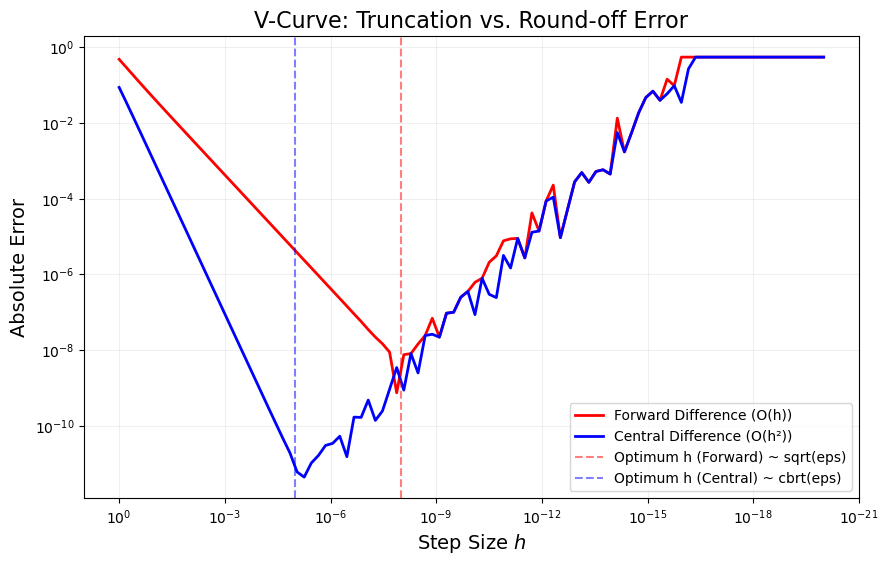

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def study_differentiation_error():
    """
    Visualizes the trade-off between truncation error and round-off error.
    Targets the derivative of sin(x) at x = 1.0.
    """
    x = 1.0
    true_derivative = np.cos(x)
    
    # Generate a range of step sizes from 10^0 down to 10^-20
    h_values = np.logspace(0, -20, 100)
    
    errors_forward = []
    errors_central = []
    
    for h in h_values:
        # Forward Difference: [f(x+h) - f(x)] / h
        df_forward = (np.sin(x + h) - np.sin(x)) / h
        errors_forward.append(abs(df_forward - true_derivative))
        
        # Central Difference: [f(x+h) - f(x-h)] / 2h
        df_central = (np.sin(x + h) - np.sin(x - h)) / (2 * h)
        errors_central.append(abs(df_central - true_derivative))

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.loglog(h_values, errors_forward, label='Forward Difference (O(h))', color='red', lw=2)
    plt.loglog(h_values, errors_central, label='Central Difference (O(h²))', color='blue', lw=2)
    
    # Theoretical optimal h markers
    plt.axvline(x=1e-8, color='red', linestyle='--', alpha=0.5, label='Optimum h (Forward) ~ sqrt(eps)')
    plt.axvline(x=1e-5, color='blue', linestyle='--', alpha=0.5, label='Optimum h (Central) ~ cbrt(eps)')

    plt.title("V-Curve: Truncation vs. Round-off Error", fontsize=16)
    plt.xlabel("Step Size $h$", fontsize=14)
    plt.ylabel("Absolute Error", fontsize=14)
    plt.gca().invert_xaxis()  # From large h to small h
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    
    print("Optimization Visualization complete. Showing plot...")
    plt.show()

if __name__ == "__main__":
    study_differentiation_error()

## Spectral Differentiation — Foundations and Chebyshev Methods

When solving differential equations numerically, we typically discretize the domain. The two most common approaches are **Local** (Finite Differences/Elements) and **Global** (Spectral Methods)

### 1. Finite Differences (FD) vs. Spectral

In Finite Differences, we approximate the derivative at a point $x_i$ using a local interpolant (usually a low-order polynomial) through a few neighboring points.

- **Accuracy**: Error typically scales as $O(h^p)$, where $h$ is the grid spacing and $p$ is the order (e.g., $2$ or $4$).

- **Locality**: The derivative at $x_i$ depends only on $x_{i-1}, x_i, x_{i+1}$.

**Spectral Methods** take this to the limit. We use a global interpolant—a single high-degree polynomial or trigonometric series—that passes through all points in the domain.

- **Accuracy**: For smooth functions, the error scales as $O(e^{-cN})$, where $N$ is the number of points. This is "exponential" or "spectral" convergence.

- **Globality**: The derivative at any point depends on every other point in the domain.

**When is it superior?**

Spectral methods are superior when the solution is very smooth (analytic or many times differentiable). If the solution has shocks or discontinuities, FD or Finite Volume methods are often more robust.

### 2. Chebyshev Polynomials and Orthogonality

To avoid the **Runge Phenomenon** (oscillations near boundaries with high-degree polynomials on uniform grids), we use non-uniform grids. For non-periodic domains, **Chebyshev polynomials** are the gold standard.

#### Definition

The Chebyshev polynomial of degree $n$, denoted $T_n(x)$, is defined on $x \in [-1, 1]$ as:


$$T_n(x) = \cos(n \arccos x)$$

Let $x = \cos \theta$, then $T_n(\cos \theta) = \cos(n\theta)$.

#### Orthogonality Relations

Spectral expansions rely on the fact that these polynomials are orthogonal with respect to the weight $w(x) = \frac{1}{\sqrt{1-x^2}}$.


$$\int_{-1}^1 T_n(x) T_m(x) \frac{dx}{\sqrt{1-x^2}} = \int_0^\pi \cos(n\theta) \cos(m\theta) d\theta$$

From trigonometric identities:


$$\int_0^\pi \cos(n\theta) \cos(m\theta) d\theta = \begin{cases} 0 & n \neq m \\ \pi & n = m = 0 \\ \pi/2 & n = m > 0 \end{cases}$$

#### Spectral Expansion

Any sufficiently smooth function $f(x)$ can be expanded as:


$$f(x) \approx \sum_{n=0}^N c_n T_n(x)$$


Where the coefficients $c_n$ are found via the projection:


$$c_n = \frac{2}{\pi c_n} \int_{-1}^1 \frac{f(x) T_n(x)}{\sqrt{1-x^2}} dx$$


(with $c_0=2, c_{n>0}=1$ for normalization).

### 3. Deriving the Chebyshev Derivative Matrix

In practice, we work in nodal space. We define $N+1$ points, the **Chebyshev-Gauss-Lobatto nodes**:


$$x_j = \cos\left( \frac{\pi j}{N} \right), \quad j = 0, \dots, N$$


These points are the extrema of $T_N(x)$ plus the boundaries.

#### The Problem

We want a matrix $D$ such that if $\mathbf{u}$ is a vector of values $f(x_j)$, then $\mathbf{u}' = D\mathbf{u}$ is a vector of the derivatives $f'(x_j)$.

#### Step 1: Polynomial Interpolation

The unique polynomial $p(x)$ of degree $N$ that interpolates $f$ at $x_j$ is:


$$p(x) = \sum_{j=0}^N f(x_j) \ell_j(x)$$


where $\ell_j(x)$ are the Lagrange basis polynomials:


$$\ell_j(x) = \prod_{i=0, i\neq j}^N \frac{x - x_i}{x_j - x_i}$$

#### Step 2: Differentiation

The entries of the derivative matrix are $D_{ij} = \ell'_j(x_i)$.
Through algebraic manipulation of the Lagrange form (or using the properties of $T_n$), we arrive at the **Chebyshev Differentiation Matrix**:

For $i \neq j$:


$$D_{ij} = \frac{c_i}{c_j} \frac{(-1)^{i+j}}{x_i - x_j}$$


where $c_0 = c_N = 2$, and $c_i = 1$ otherwise.

For the diagonal entries ($i = j$):


$$D_{ii} = -\frac{x_i}{2(1-x_i^2)}, \quad i=1, \dots, N-1$$


The corner cases are:


$$D_{00} = \frac{2N^2 + 1}{6}, \quad D_{NN} = -\frac{2N^2 + 1}{6}$$



### 4. Convergence Analysis

The error in spectral differentiation is fundamentally tied to the rate at which the Chebyshev coefficients $c_n$ decay. Since the spectral derivative is essentially the derivative of the interpolating polynomial, we analyze the truncation error: 

$$
E_N = f(x) - \sum_{n=0}^N c_n T_n(x)
$$.



#### Deriving Algebraic Convergence ($O(N^{-k})$)

Suppose $f(x)$ has $k$ continuous derivatives ($f \in C^k[-1, 1]$). We use the property that Chebyshev polynomials are related to Fourier series via $x = \cos \theta$. Let $g(\theta) = f(\cos \theta)$. The coefficients $c_n$ are the Fourier coefficients of the periodic, even function $g(\theta)$.

By integrating by parts $k$ times in the coefficient integral:

$$c_n = \frac{2}{\pi} \int_0^\pi g(\theta) \cos(n\theta) d\theta$$

After $k$ integrations by parts, the boundary terms for the even function $g$ vanish (or cancel), and we are left with a term involving the $k$-th derivative:

$$|c_n| \leq \frac{2}{\pi n^k} \int_0^\pi |g^{(k)}(\theta)| d\theta = O(n^{-k})$$

The error in the derivative $f'(x) - p'(x)$ is dominated by the first neglected term in the series, multiplied by the derivative of $T_n(x)$. Since $T_n'(x) = O(n^2)$, the differentiation error generally behaves as $O(N^{-(k-1)})$ for the function derivative, though for Chebyshev specifically, we often state the function approximation error as $O(N^{-k})$.

#### Deriving Exponential Convergence ($C e^{-\sigma N}$)

If $f(x)$ is analytic, it belongs to a much smoother class of functions than $C^k$. Analyticity implies:

1. **Infinite Smoothness**: The function has infinitely many continuous derivatives ($f \in C^\infty$).

2. **Power Series Representation**: At any point $x_0 \in [-1, 1]$, the function is equal to its Taylor series: $f(x) = \sum_{n=0}^\infty \frac{f^{(n)}(x_0)}{n!}(x-x_0)^n$ with a non-zero radius of convergence.

3. **Complex Analyticity**: The function can be extended to a complex function $f(z)$ that is holomorphic in an ellipse (the Bernstein ellipse $E_\rho$) with foci at $\pm 1$ and semi-axes sum $\rho > 1$.

The coefficients $c_n$ can be expressed via a contour integral using Cauchy's Integral Formula:

$$c_n = \frac{1}{\pi i} \oint_{\partial E_\rho} \frac{f(z)}{\sqrt{z^2 - 1} (\psi(z))^n} dz$$

where $\psi(z) = z + \sqrt{z^2 - 1}$ maps the exterior of the interval to the exterior of the unit disk. On the boundary of the ellipse $E_\rho$, $|\psi(z)| = \rho$. Therefore:

$$|c_n| \leq \frac{2 M}{\rho^n} = 2M e^{-n \ln \rho}$$

Setting $\sigma = \ln \rho$, we see that the coefficients—and consequently the approximation error—decay exponentially:

$$|f(x) - p(x)| \leq C e^{-\sigma N}$$

The value of $\sigma$ (and thus the speed of convergence) is determined by the distance to the nearest singularity of $f(z)$ in the complex plane.

### 5. Examples

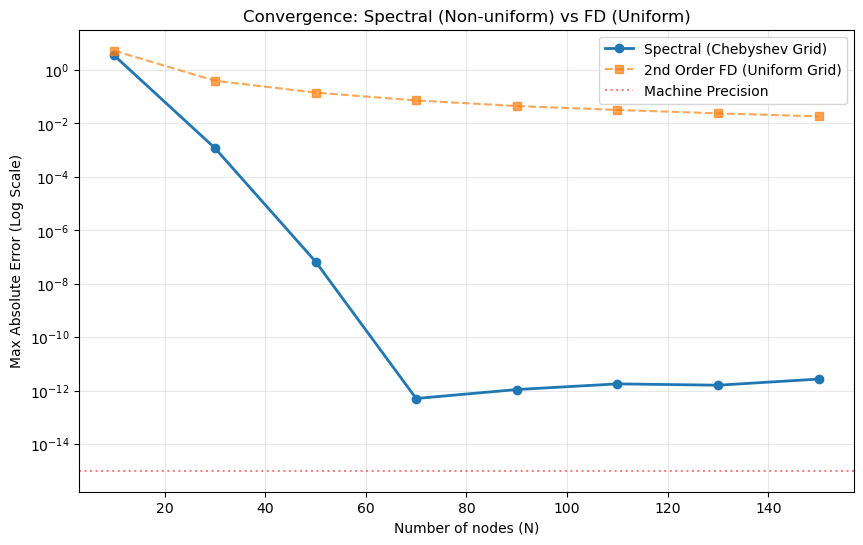

N     | Spectral Error       | Uniform FD Error    
-------------------------------------------------------
10    | 3.40e+00             | 5.13e+00            
30    | 1.18e-03             | 3.88e-01            
50    | 6.68e-08             | 1.39e-01            
70    | 5.03e-13             | 7.08e-02            
90    | 1.09e-12             | 4.38e-02            
110   | 1.77e-12             | 3.12e-02            
130   | 1.58e-12             | 2.33e-02            
150   | 2.68e-12             | 1.80e-02            


In [7]:
import numpy as np
import matplotlib.pyplot as plt


def cheb_matrix(N):
    """
    Constructs the Chebyshev differentiation matrix D for N+1 points.
    Returns: x (nodes), D (matrix)
    """
    if N == 0:
        return np.array([1.0]), np.array([0.0])

    # Chebyshev-Gauss-Lobatto nodes
    x = np.cos(np.pi * np.arange(N + 1) / N).reshape(N + 1, 1)

    # Normalization constants c_i
    c = np.ones((N + 1, 1))
    c[0] = 2.0
    c[N] = 2.0
    c = c * (-1) ** np.arange(N + 1).reshape(N + 1, 1)

    # Compute off-diagonal entries using vectorized broadcasting
    X = np.tile(x, (1, N + 1))
    dX = X - X.T

    D = (c @ (1.0 / c).T) / (dX + np.eye(N + 1))

    # Accurate diagonal entries using the negative sum trick
    D = D - np.diag(np.diag(D))  # Zero out diagonal
    D = D - np.diag(np.sum(D, axis=1))  # Set diagonal to negative sum of off-diagonals

    return x.flatten(), D


def finite_difference_uniform(f_func, N):
    """
    Computes 2nd order centered FD derivative on a standard UNIFORM grid.
    N points total on [-1, 1].
    """
    x = np.linspace(-1, 1, N)  # Standard increasing grid
    f = f_func(x)
    h = x[1] - x[0]
    df = np.zeros_like(f)

    # Interior points: 2nd order centered
    # (f(x+h) - f(x-h)) / 2h
    df[1:-1] = (f[2:] - f[0:-2]) / (2 * h)

    # Boundary points: 2nd order one-sided
    # Left boundary (x=-1)
    df[0] = (-3 * f[0] + 4 * f[1] - f[2]) / (2 * h)
    # Right boundary (x=1)
    df[-1] = (3 * f[-1] - 4 * f[-2] + f[-3]) / (2 * h)

    return x, df


# Test Function (Analytic)
f_func = lambda x: np.exp(np.sin(5 * x))
df_exact = lambda x: 5 * np.cos(5 * x) * np.exp(np.sin(5 * x))

# N values range
N_values = np.arange(10, 161, 20)
errors_spectral = []
errors_fd_uniform = []

for N_val in N_values:
    # 1. Spectral Method (on Chebyshev Grid)
    x_cheb, D = cheb_matrix(N_val - 1)  # N_val points total
    f_cheb = f_func(x_cheb)
    df_spec = D @ f_cheb
    true_cheb = df_exact(x_cheb)
    errors_spectral.append(np.max(np.abs(df_spec - true_cheb)))

    # 2. Finite Difference (on Uniform Grid)
    x_uni, df_fd = finite_difference_uniform(f_func, N_val)
    true_uni = df_exact(x_uni)
    errors_fd_uniform.append(np.max(np.abs(df_fd - true_uni)))

# Visualizing results
plt.figure(figsize=(10, 6))
plt.semilogy(
    N_values, errors_spectral, "o-", label="Spectral (Chebyshev Grid)", linewidth=2
)
plt.semilogy(
    N_values, errors_fd_uniform, "s--", label="2nd Order FD (Uniform Grid)", alpha=0.7
)

# Highlight machine epsilon floor
plt.axhline(1e-15, color="red", linestyle=":", alpha=0.5, label="Machine Precision")

plt.xlabel("Number of nodes (N)")
plt.ylabel("Max Absolute Error (Log Scale)")
plt.title("Convergence: Spectral (Non-uniform) vs FD (Uniform)")
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

# Print results
print(f"{'N':<5} | {'Spectral Error':<20} | {'Uniform FD Error':<20}")
print("-" * 55)
for i, N in enumerate(N_values):
    print(f"{N:<5} | {errors_spectral[i]:<20.2e} | {errors_fd_uniform[i]:<20.2e}")